In [20]:
import sys
from pathlib import Path
from tqdm import tqdm
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch import optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

In [7]:
cwd = Path.cwd()
project_root = cwd.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    print("Done!")

Done!


#### Hyperparameters

In [2]:
epochs = 3 # starting small to test if the loss is decresing or not.
batch_size = 128
noise_size = 128
lr = 2e-4
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#### Data Loading

In [5]:
transformation = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=(0.5,), std=(0.5,))])

In [8]:
train_dataset = datasets.MNIST(
    root=project_root / "data",
    train=True,
    transform=transformation,
)

test_dataset = datasets.MNIST(
    root=project_root / "data",
    train=False,
    transform=transformation,
)

In [9]:
train_dataloader = DataLoader(dataset=train_dataset, shuffle=True, batch_size=batch_size)
test_dataloader = DataLoader(dataset=test_dataset, shuffle=True, batch_size=batch_size)

In [10]:
next(iter(train_dataloader))

[tensor([[[[-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           ...,
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.]]],
 
 
         [[[-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           ...,
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.]]],
 
 
         [[[-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           ...,
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.]]],
 
 
         ...,
 
 
         [[[-1., -1., -1.,  ..., -

In [37]:
# Generator
class Generator(nn.Module):
    def __init__(self, noise_size:int):
        super().__init__()
        self.tanh = nn.Tanh()
        self.relu = nn.ReLU()
        self.layer1 = nn.Linear(in_features=noise_size, out_features=256)
        self.layer2 = nn.Linear(in_features=256, out_features=512)
        self.layer3 = nn.Linear(in_features=512, out_features=28*28)
    
    def forward(self, X):
        X = self.layer1(X)
        X = self.relu(X)
        X = self.layer2(X)
        X = self.relu(X)
        X = self.layer3(X)
        X = self.tanh(X)
        return X

In [38]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.lrelu = nn.LeakyReLU()
        self.sigmoid = nn.Sigmoid()
        self.layer1 = nn.Linear(in_features=28*28, out_features=512)
        self.layer2 = nn.Linear(in_features=512, out_features=256)
        self.layer3 = nn.Linear(in_features=256, out_features=1)
        
    def forward(self, X):
        X = self.layer1(X)
        X = self.lrelu(X)
        X = self.layer2(X)
        X = self.lrelu(X)
        X = self.layer3(X)
        X = self.sigmoid(X)
        return X

In [39]:
generator = Generator(noise_size).to(device)
discriminator = Discriminator().to(device)

In [40]:
criterion = nn.BCELoss()
g_optimizer = optim.Adam(generator.parameters(), lr=lr)
d_optimizer = optim.Adam(discriminator.parameters(), lr=lr)

In [47]:
def train(
    dataloader: DataLoader,
    generator: Generator,
    discriminator: Discriminator,
    criterion: nn.BCELoss,
    noise_size: int,
    batch_size: int,
    device,
    g_optimizer,
    d_optimizer,
    epochs: int = 10,
    k: int = 1
    ):
    """
    Args:
        generator (Generator): generator part of the GAN
        discriminator (Discriminator): discriminator part of the GAN
        criterion (nn.BCELoss): criterion
        epochs (int, optional): no of epochs to run. Defaults to 10.
        k (int, optional): no of times discriminator should be trained. Defaults to 1.
    """
    for epoch in range(epochs):
        g_total_loss = 0
        d_total_loss = 0
        for batch, _ in dataloader:
            for _ in range(k):
                # batch of generated samples.
                batch = batch.to(device)
                batch = batch.view(batch.shape[0], -1)
                noise_sample = torch.randn(size=[batch.shape[0], noise_size]).to(device)
                generated_samples = generator.forward(noise_sample).detach()
                g_labels = torch.zeros(size=[batch.shape[0]]).squeeze().to(device)
                r_labels = torch.ones(size=[batch.shape[0]]).squeeze().to(device)
                g_generator_output = discriminator.forward(generated_samples).squeeze()
                r_generator_output = discriminator.forward(batch).squeeze()
                g_cost = criterion(g_generator_output, g_labels)
                r_cost = criterion(r_generator_output, r_labels)
                d_optimizer.zero_grad()
                d_loss = g_cost + r_cost
                d_total_loss += d_loss.item()
                d_loss.backward()
                d_optimizer.step()
            new_noise_sample = torch.randn(size=[batch.shape[0], noise_size]).to(device)
            new_fake_samples = generator.forward(new_noise_sample)
            new_d_output = discriminator.forward(new_fake_samples).squeeze()
            new_labels = torch.ones(size=[batch.shape[0]]).to(device)
            g_optimizer.zero_grad()
            new_g_cost = criterion(new_d_output, new_labels)
            g_total_loss += new_g_cost.item()
            new_g_cost.backward()
            g_optimizer.step()
            
        print(f"Epoch {epoch+1}/{epochs} | D Loss: {d_total_loss:.4f} | G Loss: {g_total_loss:.4f}")
    return generator, discriminator

In [48]:
def visualize(generator: Generator, noise_size, device, n=16):
    generator.eval()
    with torch.no_grad():
        noise_data = torch.randn(size=[n, noise_size]).to(device)
        output = generator.forward(noise_data)
        output = output.cpu()
        output = output.view(n, 28, 28)
        output = (output + 1)/2
        
        figs, axes = plt.subplots(nrows=4, ncols=4, figsize=(8,8))
        for i in range(n):
            row = i // 4
            col = i % 4
            axes[row][col].imshow(output[i], cmap='gray')
            axes[row][col].axis('off')
    
    plt.show()

In [51]:
trained_generator, trained_discriminator = train(
    dataloader=train_dataloader,
    generator=generator,
    discriminator=discriminator,
    criterion=criterion,
    noise_size=noise_size,
    batch_size=batch_size,
    device=device,
    g_optimizer=g_optimizer,
    d_optimizer=d_optimizer,
    epochs=50,
)

Epoch 1/50 | D Loss: 222.7403 | G Loss: 1701.4556
Epoch 2/50 | D Loss: 184.9191 | G Loss: 1821.5577
Epoch 3/50 | D Loss: 235.5615 | G Loss: 1756.9070
Epoch 4/50 | D Loss: 210.9582 | G Loss: 1678.6113
Epoch 5/50 | D Loss: 225.6345 | G Loss: 1784.2056
Epoch 6/50 | D Loss: 235.5305 | G Loss: 1605.4335
Epoch 7/50 | D Loss: 209.9365 | G Loss: 1523.6695
Epoch 8/50 | D Loss: 249.4963 | G Loss: 1739.6005
Epoch 9/50 | D Loss: 213.8014 | G Loss: 1564.1859
Epoch 10/50 | D Loss: 205.8928 | G Loss: 1679.9742
Epoch 11/50 | D Loss: 201.4496 | G Loss: 1824.9644
Epoch 12/50 | D Loss: 201.7324 | G Loss: 1671.3314
Epoch 13/50 | D Loss: 214.7733 | G Loss: 1720.3403
Epoch 14/50 | D Loss: 203.0087 | G Loss: 1508.9640
Epoch 15/50 | D Loss: 215.4459 | G Loss: 1642.1692
Epoch 16/50 | D Loss: 188.1406 | G Loss: 1668.2196
Epoch 17/50 | D Loss: 190.7138 | G Loss: 1740.6094
Epoch 18/50 | D Loss: 197.6124 | G Loss: 1786.2411
Epoch 19/50 | D Loss: 189.8496 | G Loss: 1858.8882
Epoch 20/50 | D Loss: 188.1398 | G Loss:

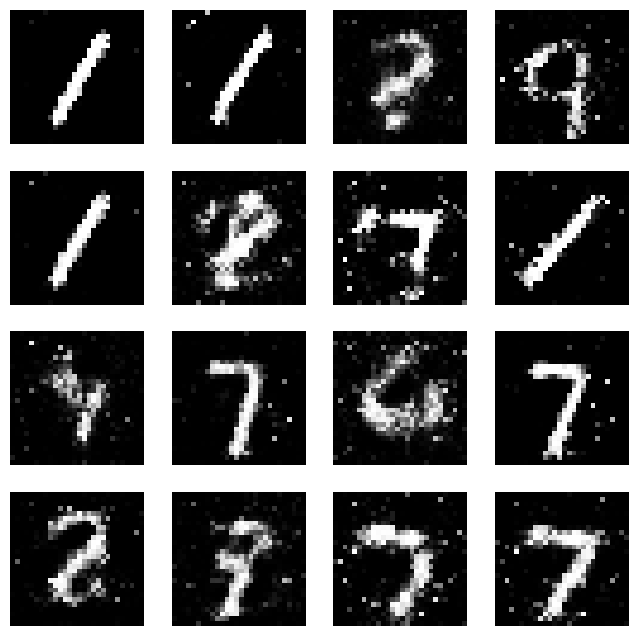

In [52]:
visualize(
    generator=trained_generator,
    noise_size=noise_size,
    device=device
)